<a href="https://colab.research.google.com/github/TheQuantSarah/tail-risk-var-analysis/blob/main/var_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

In [5]:
tickers = ["BTC-USD", "GLD", "SPY"]

prices = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-01,7200.174316,NaN,NaN
2020-01-02,6985.470215,143.949997,296.125366
2020-01-03,7344.884277,145.860001,293.883057
2020-01-04,7410.656738,NaN,NaN
2020-01-05,7411.317383,NaN,NaN


In [6]:
common_prices = prices.dropna()

common_prices.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-02,6985.470215,143.949997,296.125366
2020-01-03,7344.884277,145.860001,293.883057
2020-01-06,7769.219238,147.389999,295.004120
2020-01-07,8163.692383,147.970001,294.174683
2020-01-08,8079.862793,146.860001,295.742462


In [7]:
print("Original data:", prices.shape)
print("Common trading days:", common_prices.shape)

Original data: (2192, 3)
Common trading days: (1508, 3)


In [8]:
log_returns = np.log(common_prices / common_prices.shift(1))

log_returns.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,0.050172,0.013181,-0.007601
2020-01-06,0.056166,0.010435,0.003807
2020-01-07,0.049527,0.003927,-0.002816
2020-01-08,-0.010322,-0.007530,0.005315


In [9]:
log_returns = log_returns.dropna()

log_returns.head()

Ticker,BTC-USD,GLD,SPY
Date,,,
2020-01-03,0.050172,0.013181,-0.007601
2020-01-06,0.056166,0.010435,0.003807
2020-01-07,0.049527,0.003927,-0.002816
2020-01-08,-0.010322,-0.007530,0.005315
2020-01-09,-0.025165,-0.005668,0.006758


In [10]:
summary_stats = pd.DataFrame({
    "Mean": log_returns.mean(),
    "Std Dev": log_returns.std(),
    "Skewness": log_returns.skew(),
    "Kurtosis": log_returns.kurt()
})

summary_stats

,Mean,Std Dev,Skewness,Kurtosis
Ticker,,,,
BTC-USD,0.001677,0.039265,-1.222821,16.350805
GLD,0.000672,0.010309,-0.433609,3.189463
SPY,0.000550,0.013101,-0.558939,13.437530


In [11]:
import matplotlib.pyplot as plt

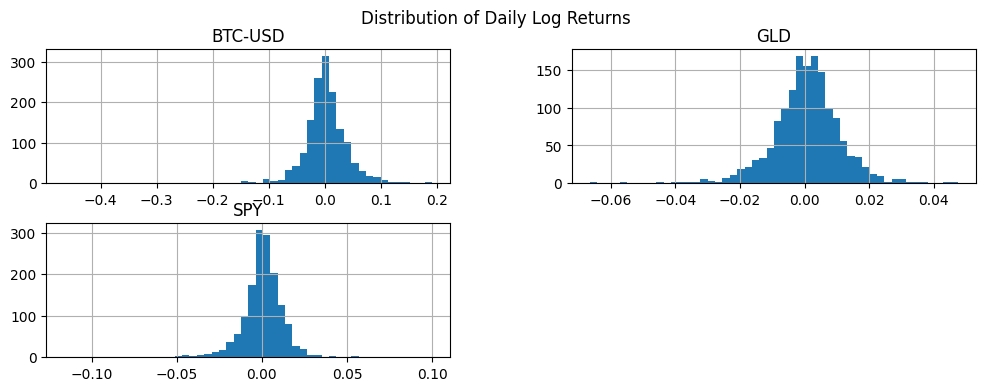

In [12]:
log_returns.hist(bins=50, figsize=(12, 4))

plt.suptitle("Distribution of Daily Log Returns")
plt.show()

In [13]:
from scipy.stats import norm

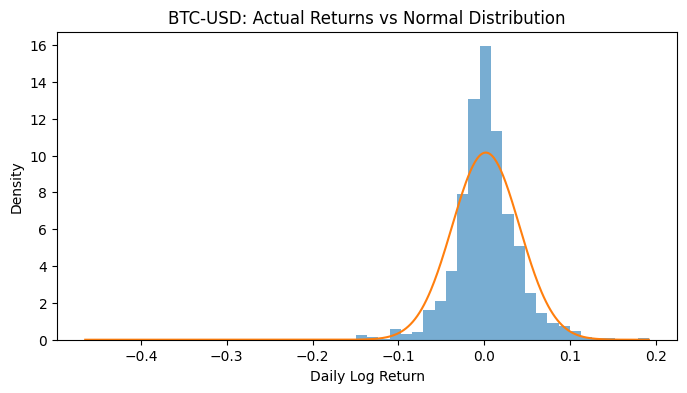

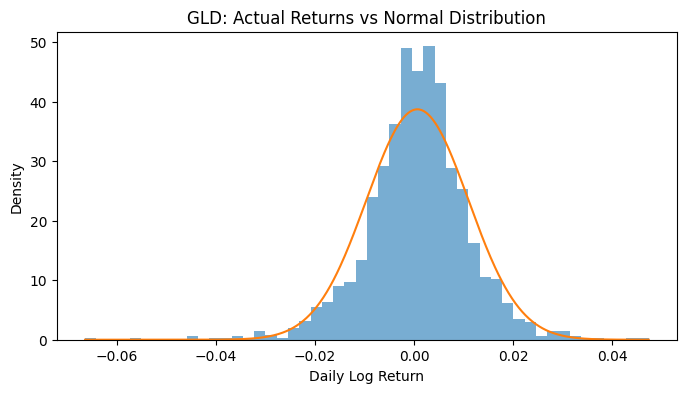

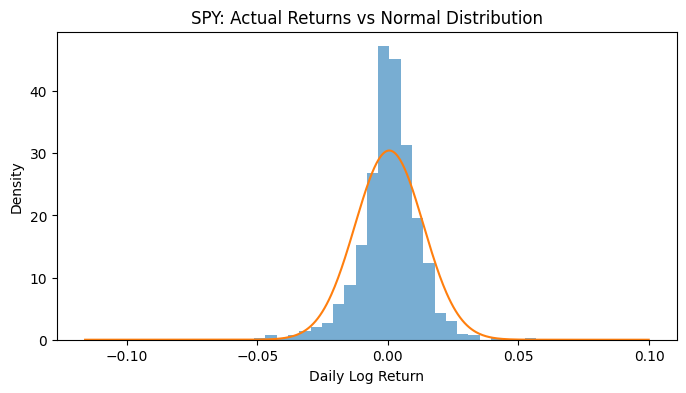

In [14]:
for asset in log_returns.columns:
    data = log_returns[asset]

    mean = data.mean()
    std = data.std()

    x = np.linspace(data.min(), data.max(), 500)

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=50, density=True, alpha=0.6)
    plt.plot(x, norm.pdf(x, mean, std))

    plt.title(f"{asset}: Actual Returns vs Normal Distribution")
    plt.xlabel("Daily Log Return")
    plt.ylabel("Density")
    plt.show()

In [15]:
  norm.pdf(x, mean, std)

array([2.13810069e-16, 2.86539387e-16, 3.83590157e-16, 5.12952955e-16,
       6.85195608e-16, 9.14278607e-16, 1.21862336e-15, 1.62251004e-15,
       2.15790460e-15, 2.86684387e-15, 3.80454562e-15, 5.04345911e-15,
       6.67853437e-15, 8.83406885e-15, 1.16725931e-14, 1.54063893e-14,
       2.03124048e-14, 2.67515389e-14, 3.51935561e-14, 4.62492278e-14,
       6.07117531e-14, 7.96100717e-14, 1.04277404e-13, 1.36439261e-13,
       1.78326324e-13, 2.32819050e-13, 3.03632685e-13, 3.95553728e-13,
       5.14741752e-13, 6.69114227e-13, 8.68836556e-13, 1.12694536e-12,
       1.46014030e-12, 1.88978879e-12, 2.44319935e-12, 3.15523341e-12,
       4.07034323e-12, 5.24514535e-12, 6.75166640e-12, 8.68143218e-12,
       1.11506127e-11, 1.43064881e-11, 1.83355651e-11, 2.34737522e-11,
       3.00191011e-11, 3.83477427e-11, 4.89337929e-11, 6.23741883e-11,
       7.94196353e-11, 1.01013129e-10, 1.28337836e-10, 1.62876547e-10,
       2.06485399e-10, 2.61485189e-10, 3.30774329e-10, 4.17968403e-10,
      

In [16]:
from scipy.stats import norm

confidence_level = 0.95
alpha = 1 - confidence_level

z_score = norm.ppf(alpha)

z_score

np.float64(-1.6448536269514722)

In [19]:
gaussian_var_95 = -(log_returns.mean() + z_score * log_returns.std())

gaussian_var_95

,0
Ticker,
BTC-USD,0.062907
GLD,0.016285
SPY,0.020998


In [21]:
def gaussian_var(returns, confidence_level):
  alpha = 1-confidence_level
  z_score= norm.ppf(alpha)
  gaussian_var= -(returns.mean()+z_score*returns.std())

  return gaussian_var

In [26]:
gaussian_var(log_returns, 0.95)

,0
Ticker,
BTC-USD,0.062907
GLD,0.016285
SPY,0.020998


In [27]:
gaussian_var(log_returns, 0.99)

,0
Ticker,
BTC-USD,0.089666
GLD,0.023310
SPY,0.029926


In [30]:
skewness = log_returns.skew()
kurtosis = log_returns.kurt()

skewness

,0
Ticker,
BTC-USD,-1.222821
GLD,-0.433609
SPY,-0.558939


In [31]:
kurtosis

,0
Ticker,
BTC-USD,16.350805
GLD,3.189463
SPY,13.437530


In [32]:
z = norm.ppf(0.05)

z_cf = (
    z
    + ((z**2 - 1) * skewness) / 6
    + ((z**3 - 3*z) * kurtosis) / 24
    - ((2*z**3 - 5*z) * skewness**2) / 36
)

z_cf

,0
Ticker,
BTC-USD,-1.634392
GLD,-1.700213
SPY,-1.526689


In [33]:
def cornish_fisher_z(confidence_level):
    alpha = 1 - confidence_level
    z = norm.ppf(alpha)

    z_cf = (
        z
        + ((z**2 - 1) * skewness) / 6
        + ((z**3 - 3*z) * kurtosis) / 24
        - ((2*z**3 - 5*z) * skewness**2) / 36
    )

    return z_cf

In [37]:
def cornish_fisher_var(confidence_level):
    z_cf = cornish_fisher_z(confidence_level)

    cf_var = -(
        log_returns.mean()
        + z_cf * log_returns.std()
    )

    return cf_var

In [40]:
cornish_fisher_var(0.95)

,0
Ticker,
BTC-USD,0.062496
GLD,0.016855
SPY,0.019450


In [41]:
cornish_fisher_var(0.95)
cornish_fisher_var(0.99)

,0
Ticker,
BTC-USD,0.252969
GLD,0.033555
SPY,0.074926


In [42]:
cf_var_95 = cornish_fisher_var(0.95)
cf_var_99 = cornish_fisher_var(0.99)

cf_results = pd.DataFrame({
    "95% Cornish-Fisher VaR": cf_var_95,
    "99% Cornish-Fisher VaR": cf_var_99
})

cf_results

,95% Cornish-Fisher VaR,99% Cornish-Fisher VaR
Ticker,,
BTC-USD,0.062496,0.252969
GLD,0.016855,0.033555
SPY,0.019450,0.074926


In [45]:
var_results = pd.DataFrame({
    "Gaussian VaR 95%": gaussian_var(log_returns, 0.95),
    "Cornish-Fisher VaR 95%": cornish_fisher_var(0.95),
    "Gaussian VaR 99%": gaussian_var(log_returns, 0.99),
    "Cornish-Fisher VaR 99%": cornish_fisher_var(0.99)
})

var_results

,Gaussian VaR 95%,Cornish-Fisher VaR 95%,Gaussian VaR 99%,Cornish-Fisher VaR 99%
Ticker,,,,
BTC-USD,0.062907,0.062496,0.089666,0.252969
GLD,0.016285,0.016855,0.023310,0.033555
SPY,0.020998,0.019450,0.029926,0.074926


In [46]:
var_results["Difference 95%"] = (
    var_results["Cornish-Fisher VaR 95%"]
    - var_results["Gaussian VaR 95%"]
)

var_results["Difference 99%"] = (
    var_results["Cornish-Fisher VaR 99%"]
    - var_results["Gaussian VaR 99%"]
)

var_results

,Gaussian VaR 95%,Cornish-Fisher VaR 95%,Gaussian VaR 99%,Cornish-Fisher VaR 99%,Difference 95%,Difference 99%
Ticker,,,,,,
BTC-USD,0.062907,0.062496,0.089666,0.252969,-0.000411,0.163303
GLD,0.016285,0.016855,0.023310,0.033555,0.000571,0.010244
SPY,0.020998,0.019450,0.029926,0.074926,-0.001548,0.045000
